In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcMjUzNDBcRG9jdW1lbnRzXEdpdEh1YlxhY2VyLTA5MTguZ2l0aHViLmlv'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

In [2]:
class Solution:
    def twoSum(self, nums: list[int], target: int) -> list[int]:
        n = len(nums)
        for i in range(n):
            for j in range(i + 1, n):
                if nums[i] + nums[j] == target:
                    return [i, j]

In [3]:
class Solution:
    def twoSum(self, nums: list[int], target: int) -> list[int]:
        seen = {}
        for i, x in enumerate(nums):
            need = target - x
            if need in seen:
                return [seen[need], i]
            seen[x] = i

In [4]:
from collections import defaultdict

class Solution:
    def groupAnagrams(self, strs: list[str]) -> list[list[str]]:
        groups = defaultdict(list)

        for s in strs:
            key = ''.join(sorted(s))
            groups[key].append(s)

        return list(groups.values())

In [5]:
from collections import defaultdict

class Solution:
    def groupAnagrams(self, strs: list[str]) -> list[list[str]]:
        groups = defaultdict(list)

        for s in strs:
            count = [0] * 26
            for ch in s:
                count[ord(ch) - ord('a')] += 1
            groups[tuple(count)].append(s)

        return list(groups.values())

In [6]:
class Solution:
    def longestConsecutive(self, nums: list[int]) -> int:
        num_set = set(nums)
        longest = 0

        for x in num_set:
            if x - 1 not in num_set:   # x 是连续段起点
                cur = x
                length = 1

                while cur + 1 in num_set:
                    cur += 1
                    length += 1

                longest = max(longest, length)

        return longest

In [7]:
class Solution:
    def longestConsecutive(self, nums: list[int]) -> int:
        length = {}
        ans = 0

        for x in nums:
            if x in length:
                continue

            left = length.get(x - 1, 0)
            right = length.get(x + 1, 0)
            cur = left + 1 + right

            length[x] = cur
            length[x - left] = cur
            length[x + right] = cur

            ans = max(ans, cur)

        return ans

In [8]:
class Solution:
    def moveZeroes(self, nums: list[int]) -> None:
        k = 0

        for x in nums:
            if x != 0:
                nums[k] = x
                k += 1

        for i in range(k, len(nums)):
            nums[i] = 0

In [9]:
class Solution:
    def moveZeroes(self, nums: list[int]) -> None:
        i = 0

        for j in range(len(nums)):
            if nums[j] != 0:
                if i != j:
                    nums[i], nums[j] = nums[j], nums[i]
                i += 1

In [10]:
class Solution:
    def maxArea(self, height: list[int]) -> int:
        l, r = 0, len(height) - 1
        ans = 0

        while l < r:
            area = (r - l) * min(height[l], height[r])
            ans = max(ans, area)

            if height[l] < height[r]:
                l += 1
            else:
                r -= 1

        return ans

In [11]:
class Solution:
    def threeSum(self, nums: list[int]) -> list[list[int]]:
        nums.sort()
        ans = []
        n = len(nums)

        for i in range(n - 2):
            if nums[i] > 0:
                break

            if i > 0 and nums[i] == nums[i - 1]:
                continue

            l, r = i + 1, n - 1

            while l < r:
                s = nums[i] + nums[l] + nums[r]

                if s < 0:
                    l += 1
                elif s > 0:
                    r -= 1
                else:
                    ans.append([nums[i], nums[l], nums[r]])

                    l += 1
                    r -= 1

                    while l < r and nums[l] == nums[l - 1]:
                        l += 1
                    while l < r and nums[r] == nums[r + 1]:
                        r -= 1

        return ans

In [12]:
if nums[i] > 0:
    break

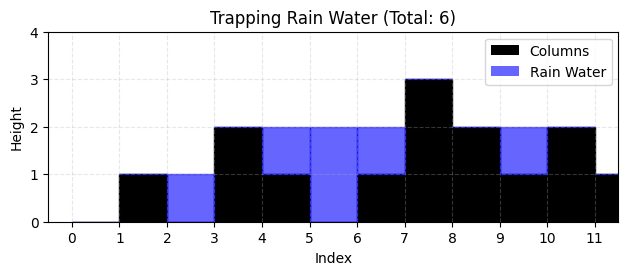

In [13]:
#| eval: true
#| echo: false
#| output: true

def visualize_rain_water_equal_aspect(heights):
    """生成接雨水问题的可视化（等比例坐标轴）"""
    import matplotlib.pyplot as plt
    import numpy as np
    
    # 计算图形大小
    n = len(heights)
    max_height = max(heights) if heights else 0
    
    # 根据数据范围设置图形大小
    fig_width = 10
    # 保持横轴和纵轴单位长度相等
    fig_height = fig_width * (max_height + 1) / (n + 2)  # 加一些边距
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    indices = np.arange(n)
    
    # 计算雨水
    if n > 0:
        left_max = [0] * n
        right_max = [0] * n
        
        left_max[0] = heights[0]
        for i in range(1, n):
            left_max[i] = max(left_max[i-1], heights[i])
        
        right_max[n-1] = heights[n-1]
        for i in range(n-2, -1, -1):
            right_max[i] = max(right_max[i+1], heights[i])
        
        water_heights = [0] * n
        for i in range(n):
            water_level = min(left_max[i], right_max[i])
            water_heights[i] = max(0, water_level - heights[i])
    else:
        water_heights = []
    
    # 绘制柱子和雨水
    ax.bar(indices, heights, width=1, 
           color='black', edgecolor='black', align='edge')
    ax.bar(indices, water_heights, width=1, bottom=heights,
           color='blue', alpha=0.6, edgecolor='blue', align='edge')
    
    # 设置坐标轴等比例
    ax.set_aspect('equal', adjustable='box')
    
    # 设置图表属性
    ax.set_xlabel('Index')
    ax.set_ylabel('Height')
    ax.set_title(f'Trapping Rain Water (Total: {sum(water_heights)})')
    ax.set_xticks(indices)
    
    # 设置网格
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # 设置坐标轴范围
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(0, max_height + 1)
    
    # 添加图例
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='black', label='Columns'),
        Patch(facecolor='blue', alpha=0.6, label='Rain Water')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return sum(water_heights)

# 运行可视化
heights = [0, 1, 0, 2, 1, 0, 1, 3, 2, 1, 2, 1]
total_water = visualize_rain_water_equal_aspect(heights)
# print(f"Total rain water: {total_water}")

In [14]:
class Solution:
    def trap(self, height: list[int]) -> int:
        n = len(height)
        if n < 3:
            return 0

        # 第一个可能形成水池的左边界：第一次下坡的位置
        i0 = next((i for i in range(n - 1) if height[i] > height[i + 1]), None)
        if i0 is None:
            return 0

        # 最后一个可能形成水池的右边界：从右看第一次下坡的位置
        j0 = next((j for j in range(n - 1, 0, -1) if height[j] > height[j - 1]), None)
        if j0 is None or i0 >= j0:
            return 0

        # 选左侧第一个全局最大值，避免多最大值时定义含糊
        max_h = max(height)
        k = height.index(max_h)

        # 从左往 k 扫，记录新的“前缀最大边界”
        left_bounds = []
        if i0 <= k:
            left_bounds.append(i0)
            last = i0
            for i in range(i0 + 1, k + 1):
                if height[i] >= height[last]:
                    left_bounds.append(i)
                    last = i

        # 从右往 k 扫，记录新的“后缀最大边界”
        right_bounds = []
        if j0 >= k:
            right_bounds.append(j0)
            last = j0
            for j in range(j0 - 1, k - 1, -1):
                if height[j] >= height[last]:
                    right_bounds.append(j)
                    last = j

        # 合并左右边界链，得到从左到右的完整边界序列
        bounds = left_bounds[:]
        for idx in reversed(right_bounds):
            if not bounds or bounds[-1] != idx:
                bounds.append(idx)

        # 前缀和：方便 O(1) 求中间柱子面积
        pref = [0] * (n + 1)
        for i, h in enumerate(height):
            pref[i + 1] = pref[i] + h

        # 对每一对相邻边界套你的面积公式
        ans = 0
        for l, r in zip(bounds, bounds[1:]):
            water_rect = (r - l - 1) * min(height[l], height[r])
            solid_area = pref[r] - pref[l + 1]
            ans += water_rect - solid_area

        return ans

In [15]:
class Solution:
    def trap(self, height: list[int]) -> int:
        n = len(height)
        left_max = [0] * n
        right_max = [0] * n

        left_max[0] = height[0]
        for i in range(1, n):
            left_max[i] = max(left_max[i - 1], height[i])

        right_max[n - 1] = height[n - 1]
        for i in range(n - 2, -1, -1):
            right_max[i] = max(right_max[i + 1], height[i])

        ans = 0
        for i in range(n):
            ans += min(left_max[i], right_max[i]) - height[i]

        return ans

In [16]:
class Solution:
    def trap(self, height: list[int]) -> int:
        l, r = 0, len(height) - 1
        left_max = right_max = 0
        ans = 0

        while l < r:
            if height[l] < height[r]:
                if height[l] >= left_max:
                    left_max = height[l]
                else:
                    ans += left_max - height[l]
                l += 1
            else:
                if height[r] >= right_max:
                    right_max = height[r]
                else:
                    ans += right_max - height[r]
                r -= 1

        return ans

In [17]:
class Solution:
    def trap(self, height: List[int]) -> int:
        res = 0
        stack = []
        for i in range(len(height)):
            while stack and height[i]>height[stack[-1]]:
                # cur=stack[-1]
                cur=stack.pop()
                if not stack:
                    break
                h=min(height[i],height[stack[-1]]) - height[cur]
                res += (i-stack[-1]-1)*h
            stack.append(i)
        return res                 

In [18]:
class Solution:
    def lengthOfLongestSubstring(self, s: str) -> int:
        seen = set()
        l = 0
        ans = 0

        for r in range(len(s)):
            while s[r] in seen:
                seen.remove(s[l])
                l += 1
            seen.add(s[r])
            ans = max(ans, r - l + 1)

        return ans

In [19]:
class Solution:
    def lengthOfLongestSubstring(self, s: str) -> int:
        last = {}
        l = 0
        ans = 0

        for r, ch in enumerate(s):
            if ch in last and last[ch] >= l:
                l = last[ch] + 1
            last[ch] = r
            ans = max(ans, r - l + 1)

        return ans

In [20]:
class Solution:
    def findAnagrams(self, s: str, p: str) -> list[int]:
        n, m = len(s), len(p)
        if m > n:
            return []

        need = [0] * 26
        window = [0] * 26

        for ch in p:
            need[ord(ch) - ord('a')] += 1

        for ch in s[:m]:
            window[ord(ch) - ord('a')] += 1

        ans = []
        if window == need:
            ans.append(0)

        for i in range(m, n):
            window[ord(s[i]) - ord('a')] += 1
            window[ord(s[i - m]) - ord('a')] -= 1

            if window == need:
                ans.append(i - m + 1)

        return ans

In [21]:
class Solution:
    def subarraySum(self, nums: list[int], k: int) -> int:
        cnt = {0: 1}
        pre = 0
        ans = 0

        for x in nums:
            pre += x
            ans += cnt.get(pre - k, 0)
            cnt[pre] = cnt.get(pre, 0) + 1

        return ans

In [22]:
from collections import deque

class Solution:
    def maxSlidingWindow(self, nums: list[int], k: int) -> list[int]:
        q = deque()   # 存下标，且对应值单调递减
        ans = []

        for i, x in enumerate(nums):
            # 1. 删除队头中已经滑出窗口的下标
            if q and q[0] <= i - k:
                q.popleft()

            # 2. 维护单调递减：把队尾比当前值小的都弹掉
            while q and nums[q[-1]] < x:
                q.pop()

            # 3. 当前下标入队
            q.append(i)

            # 4. 当窗口形成后，记录答案
            if i >= k - 1:
                ans.append(nums[q[0]])

        return ans

In [23]:
from collections import Counter, defaultdict

class Solution:
    def minWindow(self, s: str, t: str) -> str:
        if not s or not t:
            return ""

        need = Counter(t)
        window = defaultdict(int)

        required = len(need)   # 需要满足的字符种类数
        formed = 0             # 当前已经满足要求的字符种类数

        left = 0
        min_len = float('inf')
        start = 0

        for right, ch in enumerate(s):
            # 1. 扩张窗口：把 s[right] 放进来
            window[ch] += 1

            # 2. 如果这个字符刚好达到要求，formed + 1
            if ch in need and window[ch] == need[ch]:
                formed += 1

            # 3. 如果当前窗口已经覆盖 t，就尝试收缩左边界
            while formed == required:
                # 更新最短答案
                if right - left + 1 < min_len:
                    min_len = right - left + 1
                    start = left

                # 准备移出左端字符
                left_ch = s[left]
                window[left_ch] -= 1

                # 如果移出后不满足要求了，formed - 1
                if left_ch in need and window[left_ch] < need[left_ch]:
                    formed -= 1

                left += 1

        return "" if min_len == float('inf') else s[start:start + min_len]

In [24]:
from collections import Counter

t = "AABC"
need = Counter(t)
print(need)

In [25]:
class Solution:
    def maxSubArray(self, nums: list[int]) -> int:
        prefix = 0
        min_prefix = 0
        ans = float('-inf')

        for x in nums:
            prefix += x
            ans = max(ans, prefix - min_prefix)
            min_prefix = min(min_prefix, prefix)

        return ans

In [26]:
class Solution:
    def maxSubArray(self, nums: list[int]) -> int:
        cur = nums[0]
        ans = nums[0]

        for i in range(1, len(nums)):
            cur = max(nums[i], cur + nums[i])
            ans = max(ans, cur)

        return ans

In [27]:
class Status:
    def __init__(self, lSum: int, rSum: int, mSum: int, iSum: int):
        self.lSum = lSum
        self.rSum = rSum
        self.mSum = mSum
        self.iSum = iSum


class Solution:
    def maxSubArray(self, nums: list[int]) -> int:
        def push_up(left: Status, right: Status) -> Status:
            iSum = left.iSum + right.iSum
            lSum = max(left.lSum, left.iSum + right.lSum)
            rSum = max(right.rSum, right.iSum + left.rSum)
            mSum = max(left.mSum, right.mSum, left.rSum + right.lSum)
            return Status(lSum, rSum, mSum, iSum)

        def get(left: int, right: int) -> Status:
            if left == right:
                x = nums[left]
                return Status(x, x, x, x)

            mid = (left + right) // 2
            left_sub = get(left, mid)
            right_sub = get(mid + 1, right)
            return push_up(left_sub, right_sub)

        return get(0, len(nums) - 1).mSum